# TensorFlow Training Workflow

In [1]:
import json
import os
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-06-27 14:35:54.250889: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Runtime Settings


In [ ]:
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "build.sbt").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = (CURRENT_DIR / "..").resolve()

FEATURES_PATH = Path(
    os.getenv("FEATURES_PATH", str(PROJECT_ROOT / "output" / "features-stream.parquet"))
).resolve()

EPOCHS = int(os.getenv("EPOCHS", "1"))
TRAIN_BATCH_SIZE = int(os.getenv("TRAIN_BATCH_SIZE", "16"))
LEARNING_RATE = float(os.getenv("LEARNING_RATE", "0.00005"))
PATIENCE = int(os.getenv("PATIENCE", "8"))
DROPOUT_RATE = float(os.getenv("DROPOUT_RATE", "0.45"))
AUG_VERTICAL_SHIFT = float(os.getenv("AUG_VERTICAL_SHIFT", "0.12"))
AUG_HORIZONTAL_SHIFT = float(os.getenv("AUG_HORIZONTAL_SHIFT", "0.10"))
AUG_ZOOM_IN_MAX = float(os.getenv("AUG_ZOOM_IN_MAX", "0.2"))
AUG_ZOOM_OUT_MAX = float(os.getenv("AUG_ZOOM_OUT_MAX", "0.1"))
AUG_ROTATION = float(os.getenv("AUG_ROTATION", "0.04"))
AUG_CONTRAST = float(os.getenv("AUG_CONTRAST",      "0.15"))
AUG_NOISE_STDDEV = float(os.getenv("AUG_NOISE_STDDEV", "0.02"))
AUG_PREVIEW_COUNT = int(os.getenv("AUG_PREVIEW_COUNT", "20"))
INITIAL_MODEL_PATH = None
# INITIAL_MODEL_PATH = PROJECT_ROOT / "ml" / "artifacts" / "models" / "baseline-20260419-051502_best.keras"
INITIAL_EPOCH = 0

if INITIAL_MODEL_PATH is not None:
    INITIAL_MODEL_PATH = Path(INITIAL_MODEL_PATH)
    if not INITIAL_MODEL_PATH.is_absolute():
        INITIAL_MODEL_PATH = (PROJECT_ROOT / INITIAL_MODEL_PATH).resolve()

RUN_NAME = os.getenv("RUN_NAME", f"baseline-{datetime.now().strftime('%Y%m%d-%H%M%S')}")
ARTIFACTS_DIR = Path(os.getenv("ARTIFACTS_DIR", str(PROJECT_ROOT / "ml" / "artifacts"))).resolve()
MODEL_DIR = Path(os.getenv("MODEL_DIR", str(ARTIFACTS_DIR / "models"))).resolve()
METRICS_DIR = Path(os.getenv("METRICS_DIR", str(ARTIFACTS_DIR / "metrics"))).resolve()
TENSORBOARD_ROOT = Path(os.getenv("TENSORBOARD_ROOT", str(ARTIFACTS_DIR / "logs" / "tensorboard"))).resolve()
TENSORBOARD_RUN_DIR = TENSORBOARD_ROOT / RUN_NAME

for path in [MODEL_DIR, METRICS_DIR, TENSORBOARD_RUN_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FEATURES_PATH:", FEATURES_PATH)
print("INITIAL_MODEL_PATH:", INITIAL_MODEL_PATH)
print("INITIAL_EPOCH:", INITIAL_EPOCH)
print("RUN_NAME:", RUN_NAME)
print("TENSORBOARD_RUN_DIR:", TENSORBOARD_RUN_DIR)

PROJECT_ROOT: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection
FEATURES_PATH: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/output/features-stream.parquet
INITIAL_MODEL_PATH: None
INITIAL_EPOCH: 0
RUN_NAME: baseline-20260627-143603
TENSORBOARD_RUN_DIR: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/logs/tensorboard/baseline-20260627-143603


## 2. Feature Store

The feature store (`features-stream.parquet`) is produced **upstream** by the streaming consumer in train mode (`consume --mode train`)

## 3. Locate the Features Dataset


In [3]:
features_path = FEATURES_PATH
if not features_path.exists():
    raise FileNotFoundError(f"Features Parquet not found: {features_path}")

print("Features path:", features_path)

Features path: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/output/features-stream.parquet


## 4. Load the Features Dataset


In [4]:
df = pd.read_parquet(features_path)
print("Rows, Columns:", df.shape)
print(df[["split", "labelId", "featureWidth", "featureHeight"]].head())

Rows, Columns: (5856, 6)
   split  labelId  featureWidth  featureHeight
0  train        2           128            128
1  train        1           128            128
2  train        1           128            128
3  train        1           128            128
4  train        2           128            128


In [5]:
image_h = int(df["featureHeight"].iloc[0])
image_w = int(df["featureWidth"].iloc[0])
channels = 1
expected_size = image_h * image_w * channels

features = np.stack(df["features"].apply(lambda x: np.asarray(x, dtype=np.float32)).to_numpy())
labels = df["labelId"].astype(np.int32).to_numpy()
splits = df["split"].astype(str).to_numpy()

if features.shape[1] != expected_size:
    raise ValueError(
        f"Unexpected feature length: got {features.shape[1]}, expected {expected_size}."
    )

X = features.reshape((-1, image_h, image_w, channels))

y = labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5856, 128, 128, 1)
y shape: (5856,)


## 5. Build Train, Validation, and Test Splits


In [6]:
# Rebalance the validation split. The raw dataset's val split is tiny, so we
# move a deterministic random sample of train rows into val until each class
# reaches the target count.
# The test split is never touched: it stays exactly as defined on disk.
TARGET_VAL_COUNT_PER_CLASS = int(os.getenv("TARGET_VAL_COUNT_PER_CLASS", "100"))
rng = np.random.default_rng(seed=42)

for label_id in np.unique(y):
    current_val_count = int(np.sum((splits == "val") & (y == label_id)))
    missing = TARGET_VAL_COUNT_PER_CLASS - current_val_count
    if missing <= 0:
        continue

    train_indices = np.where((splits == "train") & (y == label_id))[0]
    if len(train_indices) < missing:
        raise ValueError(
            f"Not enough train rows to complete validation for labelId={label_id}: "
            f"required={missing}, available={len(train_indices)}"
        )

    moved = rng.choice(train_indices, size=missing, replace=False)
    splits[moved] = "val"

for split_name in ("train", "val", "test"):
    counts = {int(c): int(n) for c, n in zip(*np.unique(y[splits == split_name], return_counts=True))}
    print(f"{split_name}: {counts}")

train: {0: 1249, 1: 2438, 2: 1245}
val: {0: 100, 1: 100, 2: 100}
test: {0: 234, 1: 242, 2: 148}


In [7]:
train_mask = splits == "train"
val_mask = splits == "val"
test_mask = splits == "test"

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("One split is empty. Check split values in features dataset.")

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(min(len(X_train), 10000), seed=42)
    .batch(TRAIN_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(TRAIN_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(TRAIN_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Train: (4932, 128, 128, 1) (4932,)
Val: (300, 128, 128, 1) (300,)
Test: (624, 128, 128, 1) (624,)


I0000 00:00:1782563788.566869   87220 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-06-27 14:36:28.653454: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 323223552 exceeds 10% of free system memory.
2026-06-27 14:36:30.806682: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 323223552 exceeds 10% of free system memory.
2026-06-27 14:36:34.838660: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19660800 exceeds 10% of free system memory.
2026-06-27 14:36:34.898891: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19660800 exceeds 10% of free system memory.
2026-06-27 14:36:34.984206: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 40894464 exceeds 10% of free system memor

In [8]:
# Class weights: the dataset is imbalanced (~3 pneumonia for 1 normal), so an
# unweighted loss rewards "always predict pneumonia". Weight each class
# inversely to its frequency: a mistake on a rare class costs more.
num_classes = int(y_train.max()) + 1
class_counts = np.bincount(y_train.astype(int), minlength=num_classes)
class_weight = {
    class_id: len(y_train) / (num_classes * count)
    for class_id, count in enumerate(class_counts)
}
print("Class counts :", dict(enumerate(class_counts)))
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})

Class counts : {0: 1249, 1: 2438, 2: 1245}
Class weights: {0: 1.316, 1: 0.674, 2: 1.32}


## 6. Build the TensorFlow Model


In [9]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomZoom(
        height_factor=(-AUG_ZOOM_IN_MAX, AUG_ZOOM_OUT_MAX),
        width_factor=(-AUG_ZOOM_IN_MAX, AUG_ZOOM_OUT_MAX),
        fill_mode="constant",
        fill_value=0.0
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=AUG_VERTICAL_SHIFT,
        width_factor=AUG_HORIZONTAL_SHIFT,
        fill_mode="constant",
        fill_value=0.0
    ),
    tf.keras.layers.RandomRotation(
        factor=AUG_ROTATION,
        fill_mode="constant",
        fill_value=0.0
    ),
    tf.keras.layers.RandomContrast(AUG_CONTRAST),
    tf.keras.layers.GaussianNoise(AUG_NOISE_STDDEV)
], name="data_augmentation")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(image_h, image_w, channels)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT_RATE),
    tf.keras.layers.Dense(3, activation="softmax")
])

if INITIAL_MODEL_PATH is not None:
    if not INITIAL_MODEL_PATH.exists():
        raise FileNotFoundError(f"Initial model not found: {INITIAL_MODEL_PATH}")

    reference_model = tf.keras.models.load_model(
        INITIAL_MODEL_PATH
    )

    try:
        model.set_weights(reference_model.get_weights())
    except ValueError as exc:
        raise ValueError(
            "Unable to resume from the provided model because its architecture is not compatible "
            f"with the current notebook configuration: {INITIAL_MODEL_PATH}"
        ) from exc

    print(f"Resuming weights from: {INITIAL_MODEL_PATH}")
else:
    print("Starting training from randomly initialized weights.")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

model.summary()


Starting training from randomly initialized weights.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             

 Total params: 304,675 (1.16 MB)

 Trainable params: 303,779 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

## Preview Data Augmentation


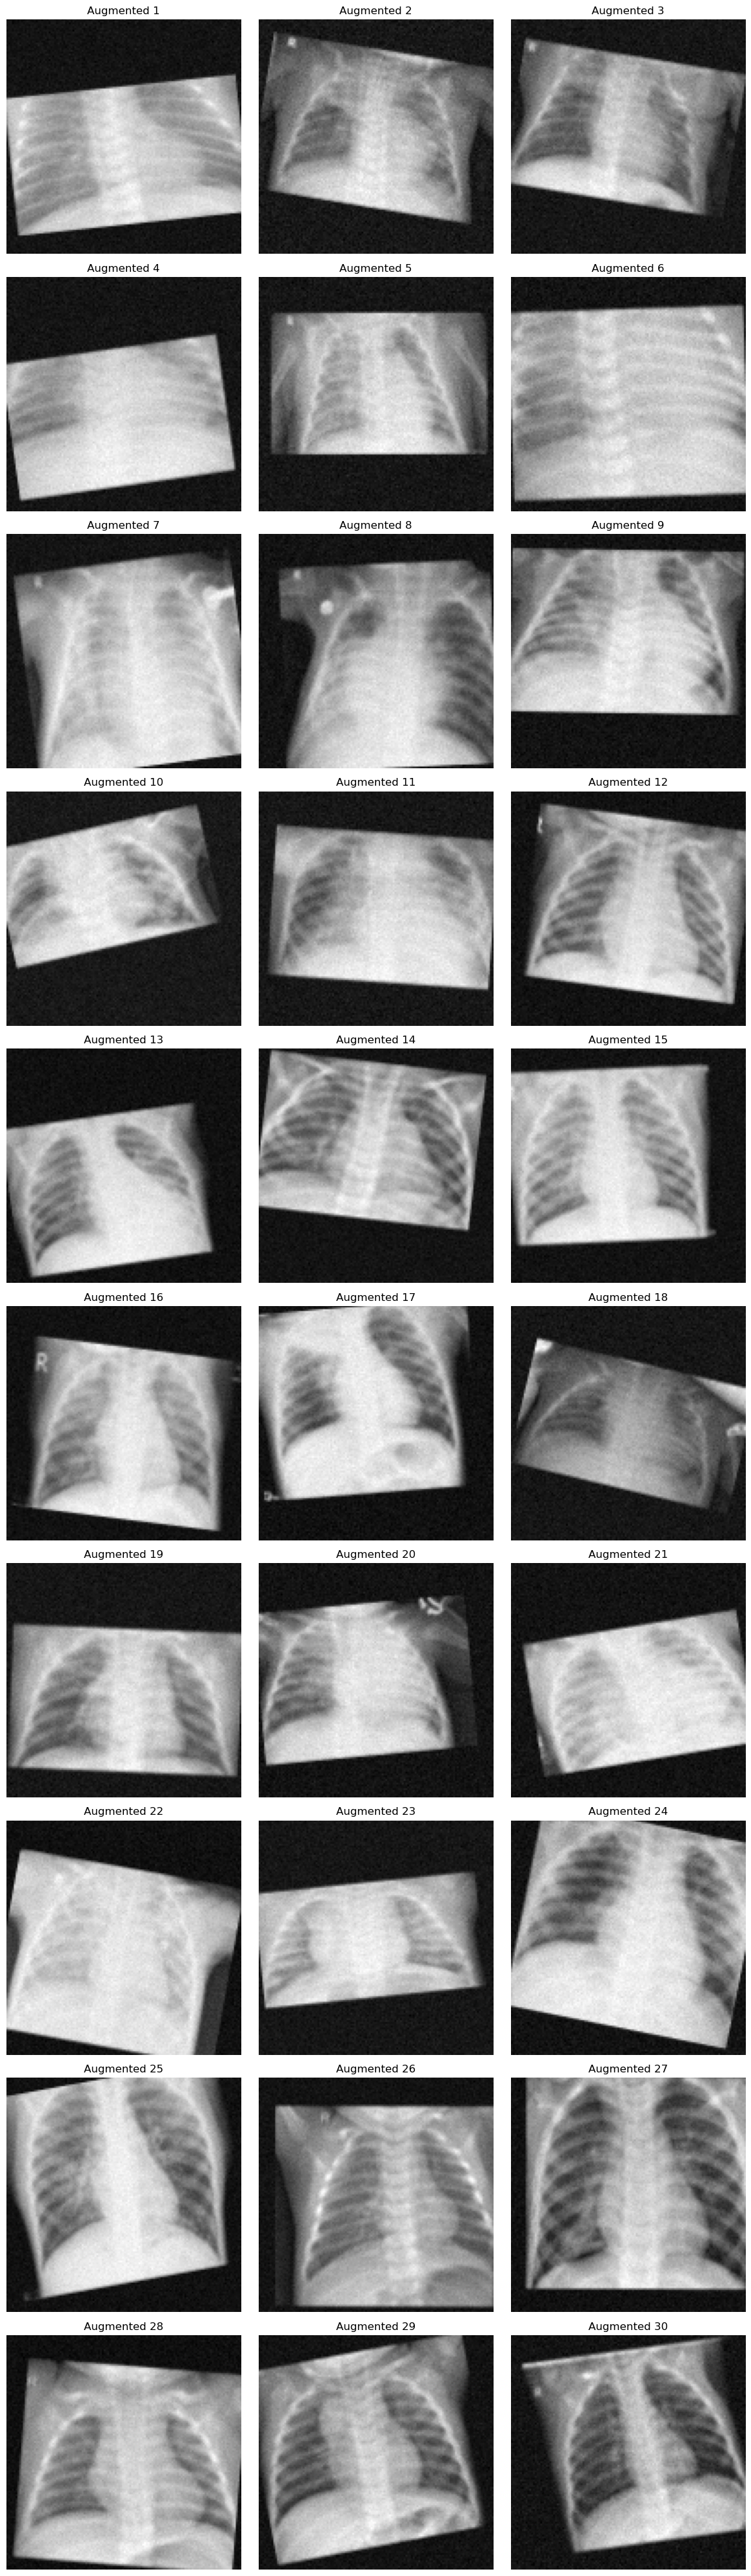

In [10]:
AUG_PREVIEW_COUNT = 30
preview_count = min(AUG_PREVIEW_COUNT, len(X_train))
preview_batch = tf.convert_to_tensor(X_train[:preview_count], dtype=tf.float32)
preview_augmented = data_augmentation(preview_batch, training=True).numpy()

preview_rows = int(np.ceil(preview_count / 3))
fig, axes = plt.subplots(preview_rows, 3, figsize=(12, 4 * preview_rows))
axes = np.atleast_2d(axes)

for ax in axes.flat:
    ax.axis("off")

for i in range(preview_count):
    ax = axes.flat[i]
    ax.imshow(np.squeeze(preview_augmented[i]), cmap="gray")
    ax.set_title(f"Augmented {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Train the Model and Save Artifacts


In [11]:
best_model_path = MODEL_DIR / f"{RUN_NAME}_best.keras"
final_model_path = MODEL_DIR / f"{RUN_NAME}_final.keras"
history_csv_path = METRICS_DIR / f"{RUN_NAME}_history.csv"
metrics_json_path = METRICS_DIR / f"{RUN_NAME}_test_metrics.json"

callbacks = [
    tf.keras.callbacks.TensorBoard(
        log_dir=str(TENSORBOARD_RUN_DIR),
        histogram_freq=1,
        write_graph=True,
        profile_batch=0
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(str(history_csv_path))
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=INITIAL_EPOCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

model.save(final_model_path)
# Export the SavedModel consumed by the Scala TensorflowPredictor (serve endpoint).
model.export(str(MODEL_DIR / "saved_model"))
current_model_registry_path = MODEL_DIR / "current_model.json"
registry_payload = {
    "keras_model": best_model_path.relative_to(PROJECT_ROOT).as_posix(),
    "saved_model": (MODEL_DIR / "saved_model").relative_to(PROJECT_ROOT).as_posix(),
}
current_model_registry_path.write_text(json.dumps(registry_payload, indent=2), encoding="utf-8")
print("Best model:", best_model_path)
print("Final model:", final_model_path)
print("Current model registry:", current_model_registry_path)
print("TensorBoard run dir:", TENSORBOARD_RUN_DIR)

2026-06-27 14:36:51.585205: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.5222 - loss: 0.9833
Epoch 1: val_loss improved from None to 2.07869, saving model to /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/models/baseline-20260627-143603_best.keras

Epoch 1: finished saving model to /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/models/baseline-20260627-143603_best.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 133s 351ms/step - accuracy: 0.5633 - loss: 0.8778 - val_accuracy: 0.3333 - val_loss: 2.0787 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 1.
INFO:tensorflow:Assets written to: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/models/saved_model/assets


INFO:tensorflow:Assets written to: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/models/saved_model/assets


Saved artifact at '/home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  131626925190864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131626925189136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131622483271440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131622483278736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131620698604176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131620698607248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131620698607440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131620698606288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131620698605712: TensorSpec(shape=(), dtype=tf.resource, name=None)

## 8. Evaluate on the Test Split


In [12]:
test_metrics = model.evaluate(test_ds, return_dict=True, verbose=1)
print("Test metrics:", test_metrics)

with open(metrics_json_path, "w", encoding="utf-8") as f:
    import json
    json.dump(test_metrics, f, indent=2)

print("History CSV:", history_csv_path)
print("Test metrics JSON:", metrics_json_path)

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3878 - loss: 2.1578
Test metrics: {'accuracy': 0.3878205120563507, 'loss': 2.1578338146209717}
History CSV: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/metrics/baseline-20260627-143603_history.csv
Test metrics JSON: /home/dan/projects/ESGI/4A/T3/Spark-Streaming/X-Ray-Pneumonia-Detection/ml/artifacts/metrics/baseline-20260627-143603_test_metrics.json
